In [64]:
import sys
import json
import logging
import warnings
from pathlib import Path
import matplotlib.pyplot as plt

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

# -------------------- Конфигурация --------------------
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "bigdata" / "processed"

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Устройство: {DEVICE}")

SEQ_LEN = 40
BATCH_SIZE = 128
EPOCHS = 50
TARGET_CONFIGS = [
    {'type': 'binary', 'col': 'target_binary_20d', 'dir': 'exp3_lstm_binary'},
    {'type': 'return', 'col': 'target_return_20d', 'dir': 'exp3_lstm_return'}
]
VAL_START = '2022-01-01'
TEST_START = '2023-01-01'

2026-05-23 02:41:10,904 [INFO] Устройство: cuda


In [65]:
# Загрузка данных
df = pd.read_parquet(PROCESSED_DIR / "combined_features.parquet")
with open(PROCESSED_DIR / "feature_columns.txt") as f:
    feature_cols = [line.strip() for line in f if line.strip()]

# Топ-50 тикеров по объёму
top_tickers = df.groupby('ticker')['volume'].mean().sort_values(ascending=False).head(50).index.tolist()
df = df[df['ticker'].isin(top_tickers)].copy()
df_original  = df.sort_values(['date', 'ticker']).reset_index(drop=True)

logger.info(f"Данные: {df_original.shape}, тикеров: {df_original['ticker'].nunique()}")

2026-05-23 02:41:11,367 [INFO] Данные: (154766, 124), тикеров: 50


In [66]:
def create_sequences(df, feature_cols, target_col, seq_len, test_start, val_start=None):
    X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
    
    for ticker in df['ticker'].unique():
        ticker_data = df[df['ticker'] == ticker].sort_values('date').copy()
        if len(ticker_data) < seq_len + 10:
            continue
        
        ticker_data[feature_cols] = ticker_data[feature_cols].ffill()
        ticker_data = ticker_data.dropna(subset=feature_cols + [target_col])
        if len(ticker_data) < seq_len + 1:
            continue
        
        # Разделение по датам
        if val_start is not None:
            train_df = ticker_data[ticker_data['date'] < val_start]
            val_df = ticker_data[(ticker_data['date'] >= val_start) & (ticker_data['date'] < test_start)]
        else:
            train_df = ticker_data[ticker_data['date'] < test_start]
            val_df = pd.DataFrame()
        test_df = ticker_data[ticker_data['date'] >= test_start].copy()
        
        if len(train_df) < seq_len + 1:
            continue
        
        # Масштабирование
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_df[feature_cols])
        test_scaled = scaler.transform(test_df[feature_cols])
        
        train_targets = train_df[target_col].values
        test_targets = test_df[target_col].values
        
        # Построение последовательностей для обучения
        for i in range(len(train_scaled) - seq_len):
            X_train.append(train_scaled[i:i+seq_len])
            y_train.append(train_targets[i+seq_len])
        
        # Построение последовательностей для валидации
        if val_start is not None and len(val_df) >= seq_len + 1:
            val_scaled = scaler.transform(val_df[feature_cols])
            val_targets = val_df[target_col].values
            for i in range(len(val_scaled) - seq_len):
                X_val.append(val_scaled[i:i+seq_len])
                y_val.append(val_targets[i+seq_len])
        
        # Построение последовательностей для теста
        for i in range(len(test_scaled) - seq_len):
            X_test.append(test_scaled[i:i+seq_len])
            y_test.append(test_targets[i+seq_len])
    
    if not X_train or not X_test:
        raise ValueError("Не удалось создать последовательности")
    
    return (np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.float32),
            np.array(X_val, dtype=np.float32) if X_val else np.array([]),
            np.array(y_val, dtype=np.float32) if y_val else np.array([]),
            np.array(X_test, dtype=np.float32), np.array(y_test, dtype=np.float32))

In [67]:
# -------------------- LSTM модель --------------------
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, num_layers=1, output_dim=1, dropout=0.5):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

2026-05-23 02:41:14,308 [INFO] Train: (116815, 40, 109), Val: (7132, 40, 109), Test: (13907, 40, 109)
Epoch 1: 100%|██████████| 913/913 [00:03<00:00, 243.50it/s]
2026-05-23 02:41:18,665 [INFO] Epoch 1: train_loss=0.6741, val_loss=0.7783, val_auc=0.3994
Epoch 2: 100%|██████████| 913/913 [00:03<00:00, 248.08it/s]
2026-05-23 02:41:22,366 [INFO] Epoch 2: train_loss=0.6350, val_loss=0.8594, val_auc=0.4166
Epoch 3: 100%|██████████| 913/913 [00:03<00:00, 254.23it/s]
2026-05-23 02:41:25,974 [INFO] Epoch 3: train_loss=0.6049, val_loss=0.8578, val_auc=0.4273
Epoch 4: 100%|██████████| 913/913 [00:03<00:00, 258.20it/s]
2026-05-23 02:41:29,529 [INFO] Epoch 4: train_loss=0.5828, val_loss=0.8672, val_auc=0.4356
Epoch 5: 100%|██████████| 913/913 [00:03<00:00, 257.25it/s]
2026-05-23 02:41:33,096 [INFO] Epoch 5: train_loss=0.5666, val_loss=0.8690, val_auc=0.4398
Epoch 6: 100%|██████████| 913/913 [00:03<00:00, 264.25it/s]
2026-05-23 02:41:36,570 [INFO] Epoch 6: train_loss=0.5535, val_loss=0.8666, val_auc

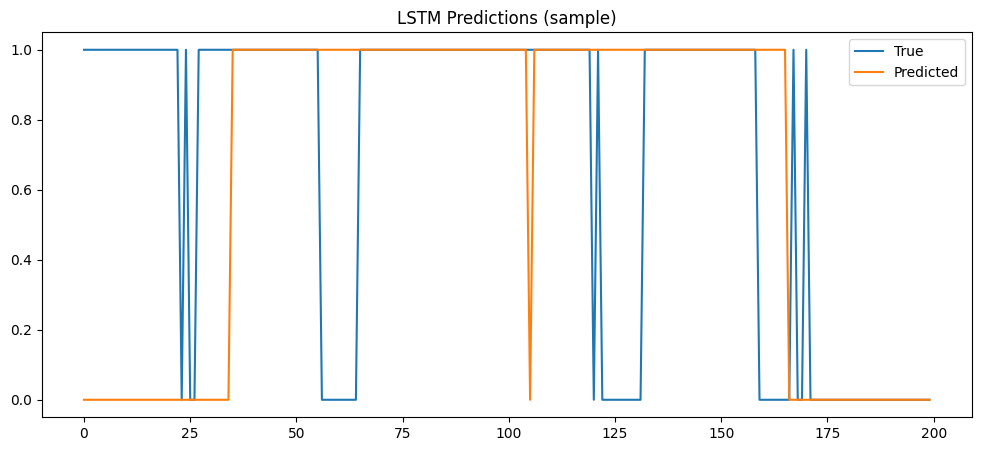

2026-05-23 02:42:26,626 [INFO] Эксперимент 3 завершён.
2026-05-23 02:42:29,383 [INFO] Train: (116815, 40, 109), Val: (7132, 40, 109), Test: (13167, 40, 109)
Epoch 1: 100%|██████████| 913/913 [00:03<00:00, 270.97it/s]
2026-05-23 02:42:33,536 [INFO] Epoch 1: train_loss=0.1839, val_loss=0.2502
Epoch 2: 100%|██████████| 913/913 [00:03<00:00, 262.90it/s]
2026-05-23 02:42:37,040 [INFO] Epoch 2: train_loss=0.1675, val_loss=0.2506
Epoch 3: 100%|██████████| 913/913 [00:03<00:00, 264.78it/s]
2026-05-23 02:42:40,514 [INFO] Epoch 3: train_loss=0.1564, val_loss=0.2509
Epoch 4: 100%|██████████| 913/913 [00:03<00:00, 271.41it/s]
2026-05-23 02:42:43,905 [INFO] Epoch 4: train_loss=0.1491, val_loss=0.2508
Epoch 5: 100%|██████████| 913/913 [00:03<00:00, 270.93it/s]
2026-05-23 02:42:47,299 [INFO] Epoch 5: train_loss=0.1444, val_loss=0.2518
Epoch 6: 100%|██████████| 913/913 [00:03<00:00, 272.29it/s]
2026-05-23 02:42:50,680 [INFO] Epoch 6: train_loss=0.1400, val_loss=0.2507
2026-05-23 02:42:50,684 [INFO] Ea

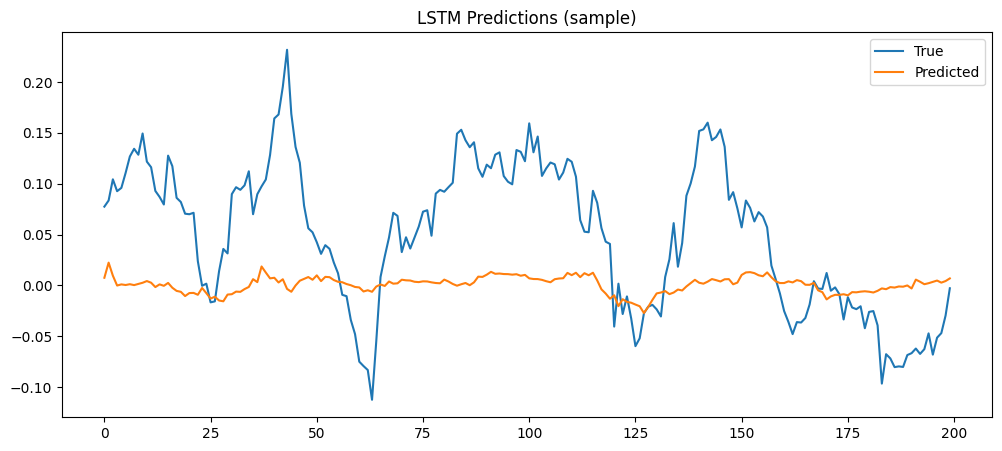

2026-05-23 02:42:51,112 [INFO] Эксперимент 3 завершён.


In [68]:
for cfg in TARGET_CONFIGS:
    TARGET_TYPE = cfg['type']
    TARGET_COL = cfg['col']
    ARTIFACTS_DIR = BASE_DIR / "artifacts" / cfg['dir']
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

    model = LSTMModel(input_dim=len(feature_cols)).to(DEVICE)
    if TARGET_TYPE == 'binary':
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

    df = df_original.copy()
    df = df.dropna(subset=[TARGET_COL])
    X_train, y_train, X_val, y_val, X_test, y_test = create_sequences(
        df, feature_cols, TARGET_COL, SEQ_LEN, TEST_START, val_start=VAL_START
    )
    
    # Нормализация таргета для регрессии
    if TARGET_TYPE == 'return':
        y_scaler = StandardScaler()
        y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        if len(y_val) > 0:
            y_val = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
    
    logger.info(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    # DataLoader
    dataset = TensorDataset(torch.tensor(X_train).to(DEVICE), torch.tensor(y_train).to(DEVICE))
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    best_loss = float('inf')
    patience = 5
    counter = 0

    X_val_t = torch.tensor(X_val).to(DEVICE)
    y_val_t = torch.tensor(y_val).to(DEVICE)

    best_auc = -np.inf
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for batch_x, batch_y in tqdm(loader, desc=f'Epoch {epoch+1}'):
            optimizer.zero_grad()
            pred = model(batch_x).squeeze()
            loss = criterion(pred, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).squeeze()
            val_loss = criterion(val_pred, y_val_t).item()
            if TARGET_TYPE == 'binary':
                val_proba = torch.sigmoid(val_pred).cpu().numpy()
                val_auc = roc_auc_score(y_val, val_proba)
            else:
                val_auc = -val_loss   # fallback

        # Сохраняем лучшую модель по AUC
        if TARGET_TYPE == 'binary':
            logger.info(f"Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_loss={val_loss:.4f}, val_auc={val_auc:.4f}")
            if val_auc > best_auc:
                best_auc = val_auc
                torch.save(model.state_dict(), ARTIFACTS_DIR / 'best_lstm.pt')
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    logger.info(f"Early stopping на эпохе {epoch+1}")
                    break
        else:
            # для регрессии оставляем loss
            logger.info(f"Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_loss={val_loss:.4f}")
            if val_loss < best_loss:
                best_loss = val_loss
                torch.save(model.state_dict(), ARTIFACTS_DIR / 'best_lstm.pt')
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    logger.info(f"Early stopping на эпохе {epoch+1}")
                    break
        scheduler.step(val_loss)

    # Тестирование
    model.load_state_dict(torch.load(ARTIFACTS_DIR / 'best_lstm.pt'))
    model.eval()
    with torch.no_grad():
        X_test_t = torch.tensor(X_test).to(DEVICE)
        y_pred_logits = model(X_test_t).squeeze().cpu().numpy()

    if TARGET_TYPE == 'binary':
        y_pred_proba = 1 / (1 + np.exp(-y_pred_logits))
        y_pred = (y_pred_proba >= 0.5).astype(int)
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'auc': roc_auc_score(y_test, y_pred_proba),
        }
    else:
        y_pred_logits = y_scaler.inverse_transform(y_pred_logits.reshape(-1, 1)).flatten()
        metrics = {
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred_logits)),
            'mae': mean_absolute_error(y_test, y_pred_logits),
            'r2': r2_score(y_test, y_pred_logits)
        }

    logger.info(f"Результаты LSTM: {metrics}")
    with open(ARTIFACTS_DIR / 'metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2, default=str)

    # График
    plt.figure(figsize=(12,5))
    plt.plot(y_test[:200], label='True')
    if TARGET_TYPE == 'binary':
        plt.plot(y_pred[:200], label='Predicted')
    else:
        plt.plot(y_pred_logits[:200], label='Predicted')
    plt.legend()
    plt.title('LSTM Predictions (sample)')
    plt.savefig(ARTIFACTS_DIR / 'predictions_sample.png', dpi=150)
    plt.show()

    logger.info("Эксперимент 3 завершён.")

In [69]:
class ImprovedLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=3, output_dim=1, dropout=0.5, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=dropout, 
                            bidirectional=bidirectional)
        self.bn = nn.BatchNorm1d(hidden_dim * (2 if bidirectional else 1))
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]                     # последний выход
        out = self.bn(out)
        out = self.dropout(out)
        return self.fc(out)

2026-05-23 02:42:53,871 [INFO] Train: (116815, 40, 109), Val: (7132, 40, 109), Test: (13907, 40, 109)
Epoch 1: 100%|██████████| 913/913 [00:16<00:00, 54.28it/s]
2026-05-23 02:43:11,924 [INFO] Epoch 1: train_loss=0.6173, val_loss=1.1243, val_auc=0.4315
Epoch 2: 100%|██████████| 913/913 [00:16<00:00, 53.80it/s]
2026-05-23 02:43:29,548 [INFO] Epoch 2: train_loss=0.4842, val_loss=1.2411, val_auc=0.4613
Epoch 3: 100%|██████████| 913/913 [00:17<00:00, 53.63it/s]
2026-05-23 02:43:47,232 [INFO] Epoch 3: train_loss=0.3998, val_loss=1.3702, val_auc=0.4365
Epoch 4: 100%|██████████| 913/913 [00:17<00:00, 53.43it/s]
2026-05-23 02:44:04,965 [INFO] Epoch 4: train_loss=0.3455, val_loss=1.5232, val_auc=0.4175
Epoch 5: 100%|██████████| 913/913 [00:17<00:00, 53.13it/s]
2026-05-23 02:44:22,807 [INFO] Epoch 5: train_loss=0.3113, val_loss=1.6485, val_auc=0.4239
Epoch 6: 100%|██████████| 913/913 [00:17<00:00, 52.13it/s]
2026-05-23 02:44:40,971 [INFO] Epoch 6: train_loss=0.2482, val_loss=1.9392, val_auc=0.426

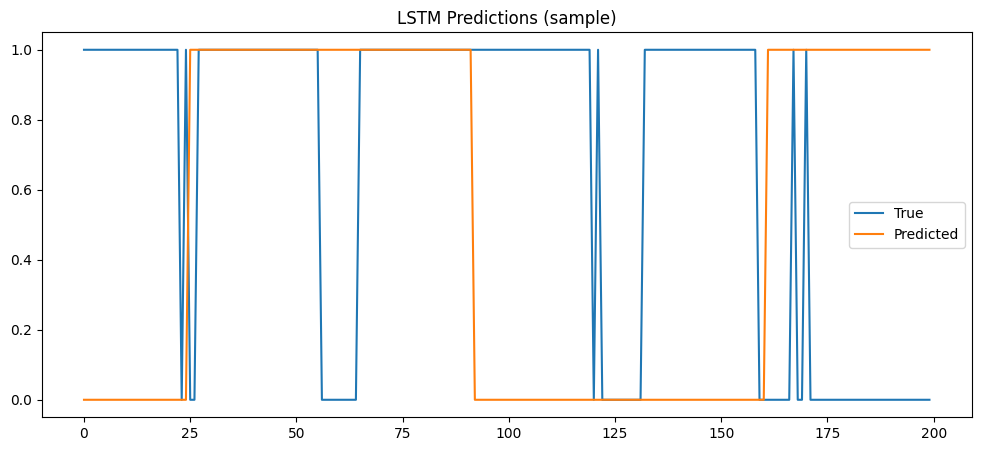

2026-05-23 02:45:14,332 [INFO] Эксперимент 3 завершён.
2026-05-23 02:45:17,083 [INFO] Train: (116815, 40, 109), Val: (7132, 40, 109), Test: (13167, 40, 109)
Epoch 1: 100%|██████████| 913/913 [02:18<00:00,  6.59it/s]
2026-05-23 02:47:42,661 [INFO] Epoch 1: train_loss=0.1732, val_loss=0.3438
Epoch 2: 100%|██████████| 913/913 [02:17<00:00,  6.62it/s]
2026-05-23 02:50:06,654 [INFO] Epoch 2: train_loss=0.1172, val_loss=0.3393
Epoch 3: 100%|██████████| 913/913 [02:18<00:00,  6.60it/s]
2026-05-23 02:52:31,348 [INFO] Epoch 3: train_loss=0.0898, val_loss=0.3585
Epoch 4: 100%|██████████| 913/913 [02:18<00:00,  6.59it/s]
2026-05-23 02:54:56,092 [INFO] Epoch 4: train_loss=0.0723, val_loss=0.3385
Epoch 5: 100%|██████████| 913/913 [02:18<00:00,  6.61it/s]
2026-05-23 02:57:20,419 [INFO] Epoch 5: train_loss=0.0637, val_loss=0.3485
Epoch 6: 100%|██████████| 913/913 [02:18<00:00,  6.61it/s]
2026-05-23 02:59:44,816 [INFO] Epoch 6: train_loss=0.0578, val_loss=0.3356
Epoch 7: 100%|██████████| 913/913 [02:1

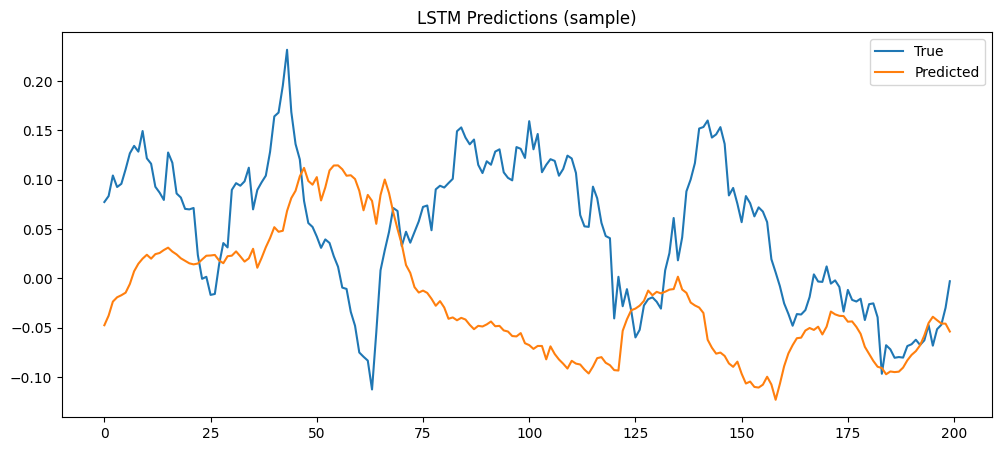

2026-05-23 03:16:48,659 [INFO] Эксперимент 3 завершён.


In [70]:
for cfg in TARGET_CONFIGS:
    TARGET_TYPE = cfg['type']
    TARGET_COL = cfg['col']
    ARTIFACTS_DIR = BASE_DIR / "artifacts" / cfg['dir']
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

    model = ImprovedLSTM(input_dim=len(feature_cols)).to(DEVICE)
    if TARGET_TYPE == 'binary':
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

    df = df_original.copy()
    df = df.dropna(subset=[TARGET_COL])
    X_train, y_train, X_val, y_val, X_test, y_test = create_sequences(
        df, feature_cols, TARGET_COL, SEQ_LEN, TEST_START, val_start=VAL_START
    )
    
    # Нормализация таргета для регрессии
    if TARGET_TYPE == 'return':
        y_scaler = StandardScaler()
        y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        if len(y_val) > 0:
            y_val = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
    
    logger.info(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    # DataLoader
    dataset = TensorDataset(torch.tensor(X_train).to(DEVICE), torch.tensor(y_train).to(DEVICE))
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    best_loss = float('inf')
    patience = 5
    counter = 0

    X_val_t = torch.tensor(X_val).to(DEVICE)
    y_val_t = torch.tensor(y_val).to(DEVICE)

    best_auc = -np.inf
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for batch_x, batch_y in tqdm(loader, desc=f'Epoch {epoch+1}'):
            optimizer.zero_grad()
            pred = model(batch_x).squeeze()
            loss = criterion(pred, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).squeeze()
            val_loss = criterion(val_pred, y_val_t).item()
            if TARGET_TYPE == 'binary':
                val_proba = torch.sigmoid(val_pred).cpu().numpy()
                val_auc = roc_auc_score(y_val, val_proba)
            else:
                val_auc = -val_loss   # fallback

        # Сохраняем лучшую модель по AUC
        if TARGET_TYPE == 'binary':
            logger.info(f"Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_loss={val_loss:.4f}, val_auc={val_auc:.4f}")
            if val_auc > best_auc:
                best_auc = val_auc
                torch.save(model.state_dict(), ARTIFACTS_DIR / 'best_lstm.pt')
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    logger.info(f"Early stopping на эпохе {epoch+1}")
                    break
        else:
            # для регрессии оставляем loss
            logger.info(f"Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_loss={val_loss:.4f}")
            if val_loss < best_loss:
                best_loss = val_loss
                torch.save(model.state_dict(), ARTIFACTS_DIR / 'best_lstm.pt')
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    logger.info(f"Early stopping на эпохе {epoch+1}")
                    break
        scheduler.step(val_loss)

    # Тестирование
    model.load_state_dict(torch.load(ARTIFACTS_DIR / 'best_lstm.pt'))
    model.eval()
    with torch.no_grad():
        X_test_t = torch.tensor(X_test).to(DEVICE)
        y_pred_logits = model(X_test_t).squeeze().cpu().numpy()

    if TARGET_TYPE == 'binary':
        y_pred_proba = 1 / (1 + np.exp(-y_pred_logits))
        y_pred = (y_pred_proba >= 0.5).astype(int)
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'auc': roc_auc_score(y_test, y_pred_proba),
        }
    else:
        y_pred_logits = y_scaler.inverse_transform(y_pred_logits.reshape(-1, 1)).flatten()
        metrics = {
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred_logits)),
            'mae': mean_absolute_error(y_test, y_pred_logits),
            'r2': r2_score(y_test, y_pred_logits)
        }

    logger.info(f"Результаты LSTM: {metrics}")
    with open(ARTIFACTS_DIR / 'metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2, default=str)

    # График
    plt.figure(figsize=(12,5))
    plt.plot(y_test[:200], label='True')
    if TARGET_TYPE == 'binary':
        plt.plot(y_pred[:200], label='Predicted')
    else:
        plt.plot(y_pred_logits[:200], label='Predicted')
    plt.legend()
    plt.title('LSTM Predictions (sample)')
    plt.savefig(ARTIFACTS_DIR / 'predictions_sample.png', dpi=150)
    plt.show()

    logger.info("Эксперимент 3 завершён.")